# Machine Learning Course  
## Lesson 02 — Linear Regression

**Previous lesson:** Linear Algebra  
**Next lesson:** Polynomial Regression

### Lesson Focus

Ordinary least squares, evaluation metrics, and residual analysis.

### Learning Objectives

By the end of this notebook, learners should be able to:

- explain the central concepts presented in this lesson;
- implement the relevant method using Python;
- evaluate the resulting model or computation appropriately;
- interpret outputs rather than reporting values without context;
- identify common implementation and modeling mistakes.

### Prerequisites

Familiarity with Python, NumPy, pandas, Matplotlib, and the concepts introduced in the preceding lesson.

### Reproducibility Standard

All data splits and stochastic estimators should use a fixed random seed. Preprocessing must be learned from training data only, preferably through a pipeline.

# Linear Regression

A practical and mathematical introduction to simple and multiple linear regression using NumPy, Matplotlib, and scikit-learn.

---

## Learning Objectives

By the end of this notebook, learners should be able to:

- explain the intuition behind linear regression;
- distinguish simple from multiple linear regression;
- interpret regression coefficients;
- estimate a regression line manually;
- solve linear regression using the normal equation;
- train models using scikit-learn;
- evaluate predictions using MAE, MSE, RMSE, and \(R^2\);
- inspect residuals and identify possible model limitations.

## Prerequisites

- Basic Python
- NumPy arrays
- Introductory statistics
- Basic data visualization

**Estimated duration:** 90–120 minutes

## Table of Contents

1. Required Libraries  
2. Linear Regression Intuition  
3. Simple Linear Regression from Scratch  
4. scikit-learn Verification  
5. Regression Evaluation Metrics  
6. Normal Equation  
7. Gradient Descent  
8. Multiple Linear Regression  
9. Residual Analysis  
10. Common Mistakes and Best Practices  
11. Exercises  
12. Key Takeaways  
13. References

## 1. Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 2. Linear Regression Intuition

Linear regression models the relationship between one or more input features and a continuous target.

For one feature, the model is:

\[
\hat{y} = \beta_0 + \beta_1 x
\]

where:

- \(\hat{y}\) is the predicted target;
- \(\beta_0\) is the intercept;
- \(\beta_1\) is the slope;
- \(x\) is the input feature.

The fitted line minimizes the sum of squared residuals:

\[
\text{SSE} = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

A residual is the difference between the observed and predicted value:

\[
e_i = y_i-\hat{y}_i
\]

## 3. Simple Linear Regression from Scratch

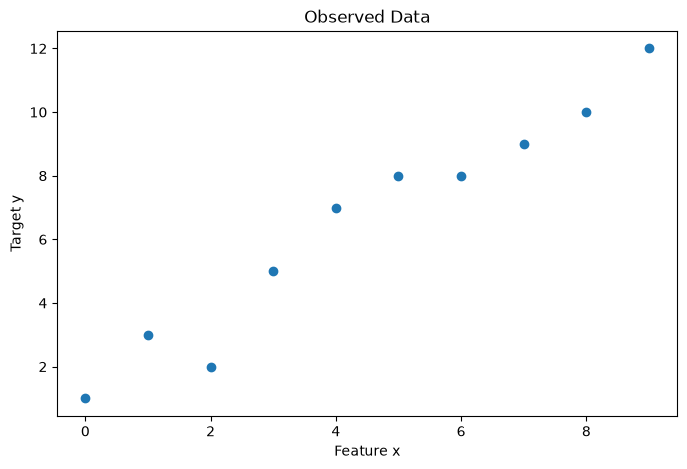

In [2]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=float)
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12], dtype=float)

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.title("Observed Data")
plt.show()

For simple linear regression, the slope and intercept can be estimated as:

\[
\beta_1 =
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
\]

\[
\beta_0 = \bar{y}-\beta_1\bar{x}
\]

In [3]:
def estimate_coefficients(x_values: np.ndarray, y_values: np.ndarray) -> tuple[float, float]:
    if x_values.ndim != 1 or y_values.ndim != 1:
        raise ValueError("x_values and y_values must be one-dimensional.")
    if len(x_values) != len(y_values):
        raise ValueError("x_values and y_values must have equal length.")
    if np.isclose(np.var(x_values), 0):
        raise ValueError("The feature must contain variation.")

    x_mean = np.mean(x_values)
    y_mean = np.mean(y_values)

    slope = np.sum((x_values - x_mean) * (y_values - y_mean)) / np.sum(
        (x_values - x_mean) ** 2
    )
    intercept = y_mean - slope * x_mean
    return intercept, slope


intercept_manual, slope_manual = estimate_coefficients(x, y)
y_pred_manual = intercept_manual + slope_manual * x

print(f"Intercept: {intercept_manual:.4f}")
print(f"Slope:     {slope_manual:.4f}")

Intercept: 1.2364
Slope:     1.1697


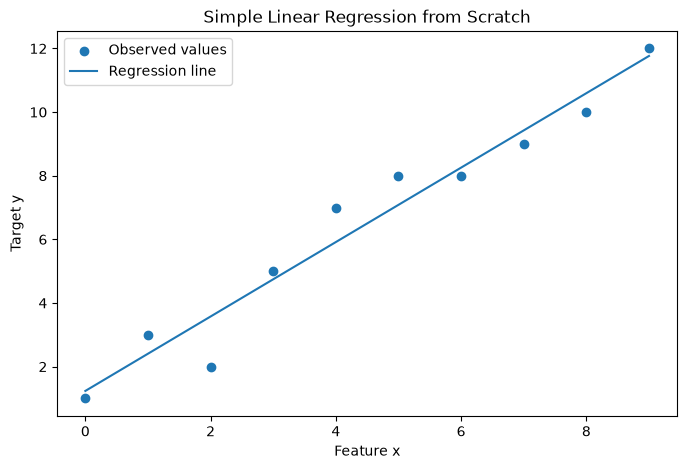

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Observed values")
plt.plot(x, y_pred_manual, label="Regression line")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.title("Simple Linear Regression from Scratch")
plt.legend()
plt.show()

### Interpretation

The slope estimates the expected change in the target for a one-unit increase in the feature. The intercept is the predicted target when the feature equals zero.

## 4. scikit-learn Verification

In [5]:
simple_model = LinearRegression()
simple_model.fit(x.reshape(-1, 1), y)

y_pred_sklearn = simple_model.predict(x.reshape(-1, 1))

print(f"scikit-learn intercept: {simple_model.intercept_:.4f}")
print(f"scikit-learn slope:     {simple_model.coef_[0]:.4f}")
print(
    "Predictions match manual solution:",
    np.allclose(y_pred_manual, y_pred_sklearn),
)

scikit-learn intercept: 1.2364
scikit-learn slope:     1.1697
Predictions match manual solution: True


## 5. Regression Evaluation Metrics

Common regression metrics include:

- **MAE:** average absolute prediction error;
- **MSE:** average squared prediction error;
- **RMSE:** square root of MSE, expressed in target units;
- **\(R^2\):** proportion of target variance explained by the model.

No single metric is sufficient in every situation. Metrics should be interpreted in relation to the target scale and the practical cost of errors.

In [6]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.Series:
    mse = mean_squared_error(y_true, y_pred)
    return pd.Series(
        {
            "MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R2": r2_score(y_true, y_pred),
        }
    )


simple_metrics = regression_metrics(y, y_pred_sklearn)
simple_metrics.to_frame("Simple linear regression")

,Simple linear regression
MAE,0.616970
MSE,0.562424
RMSE,0.749949
R2,0.952538


## 6. Normal Equation

For a feature matrix \(X\), the ordinary least-squares solution can be written as:

\[
\boldsymbol{\beta} = (X^T X)^{-1}X^Ty
\]

In practice, direct matrix inversion may be numerically unstable. The Moore–Penrose pseudoinverse is safer:

\[
\boldsymbol{\beta} = X^{+}y
\]

In [7]:
X_design = np.column_stack([np.ones(len(x)), x])
beta_normal = np.linalg.pinv(X_design) @ y

print(f"Normal-equation intercept: {beta_normal[0]:.4f}")
print(f"Normal-equation slope:     {beta_normal[1]:.4f}")

Normal-equation intercept: 1.2364
Normal-equation slope:     1.1697


In [8]:
new_x = np.array([-2.0, 4.0, 12.0])
new_design = np.column_stack([np.ones(len(new_x)), new_x])
new_predictions = new_design @ beta_normal

pd.DataFrame({"x": new_x, "predicted_y": new_predictions})

,x,predicted_y
0,-2.0,-1.103030
1,4.0,5.915152
2,12.0,15.272727


### Practical Note

The closed-form solution is useful for understanding the mathematics. For real projects, established libraries are preferable because they handle numerical stability, validation, and model interfaces more reliably.

## 7. Gradient Descent

Gradient descent iteratively updates the parameters to reduce mean squared error:

\[
\beta_0 \leftarrow \beta_0 - \alpha \frac{\partial J}{\partial \beta_0}
\]

\[
\beta_1 \leftarrow \beta_1 - \alpha \frac{\partial J}{\partial \beta_1}
\]

where \(\alpha\) is the learning rate.

In [9]:
def fit_gradient_descent(
    x_values: np.ndarray,
    y_values: np.ndarray,
    learning_rate: float = 0.01,
    iterations: int = 5000,
) -> tuple[float, float, list[float]]:
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")
    if iterations <= 0:
        raise ValueError("iterations must be positive.")

    intercept = 0.0
    slope = 0.0
    n_samples = len(x_values)
    history = []

    for _ in range(iterations):
        predictions = intercept + slope * x_values
        errors = predictions - y_values

        intercept_gradient = (2 / n_samples) * np.sum(errors)
        slope_gradient = (2 / n_samples) * np.sum(errors * x_values)

        intercept -= learning_rate * intercept_gradient
        slope -= learning_rate * slope_gradient

        history.append(np.mean(errors**2))

    return intercept, slope, history


gd_intercept, gd_slope, cost_history = fit_gradient_descent(
    x, y, learning_rate=0.01, iterations=5000
)

print(f"Gradient-descent intercept: {gd_intercept:.4f}")
print(f"Gradient-descent slope:     {gd_slope:.4f}")

Gradient-descent intercept: 1.2364
Gradient-descent slope:     1.1697


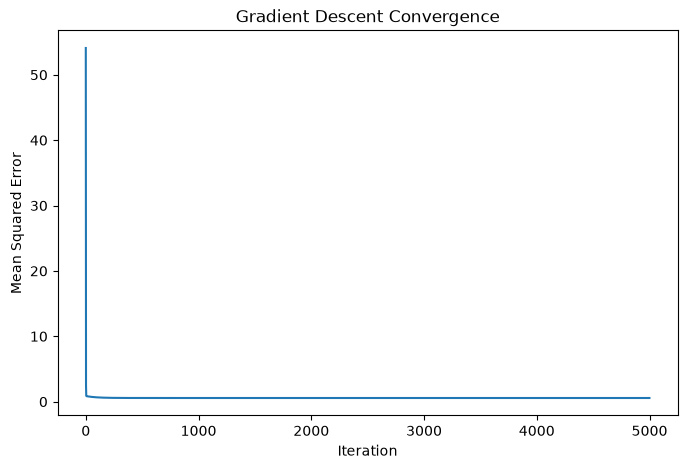

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Convergence")
plt.show()

The cost should decrease and stabilize. A learning rate that is too large may cause divergence, while a very small rate may converge slowly.

## 8. Multiple Linear Regression

Multiple linear regression extends the model to several features:

\[
\hat{y}
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+\cdots+
\beta_px_p
\]

The diabetes dataset bundled with scikit-learn is used here to keep the notebook reproducible and avoid deprecated datasets.

In [11]:
diabetes = load_diabetes(as_frame=True)
X_multi = diabetes.data
y_multi = diabetes.target

print("Feature matrix shape:", X_multi.shape)
print("Target shape:", y_multi.shape)
X_multi.head()

Feature matrix shape: (442, 10)
Target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

train_predictions = multiple_model.predict(X_train)
test_predictions = multiple_model.predict(X_test)

comparison = pd.DataFrame(
    {
        "Training": regression_metrics(y_train.to_numpy(), train_predictions),
        "Testing": regression_metrics(y_test.to_numpy(), test_predictions),
    }
)
comparison

,Training,Testing
MAE,43.483504,42.794095
MSE,2868.549703,2900.193628
RMSE,53.558843,53.853446
R2,0.527919,0.452603


### Interpretation

Training and testing performance should be compared. A large performance gap may indicate overfitting, while poor performance on both sets may indicate underfitting or an unsuitable model form.

In [13]:
coefficient_table = (
    pd.DataFrame(
        {
            "Feature": X_multi.columns,
            "Coefficient": multiple_model.coef_,
        }
    )
    .assign(Absolute_Coefficient=lambda frame: frame["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
)

coefficient_table

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


Coefficients represent estimated feature effects while all other included features are held constant. Their magnitudes are directly comparable here because the diabetes features are standardized.

## 9. Residual Analysis

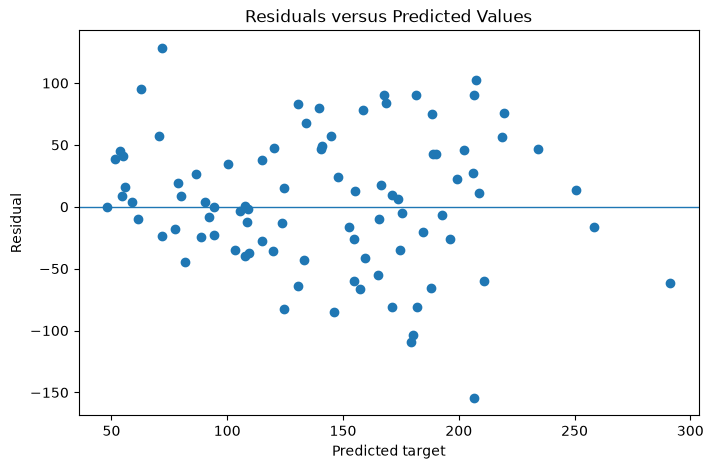

In [14]:
test_residuals = y_test.to_numpy() - test_predictions

plt.figure(figsize=(8, 5))
plt.scatter(test_predictions, test_residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted target")
plt.ylabel("Residual")
plt.title("Residuals versus Predicted Values")
plt.show()

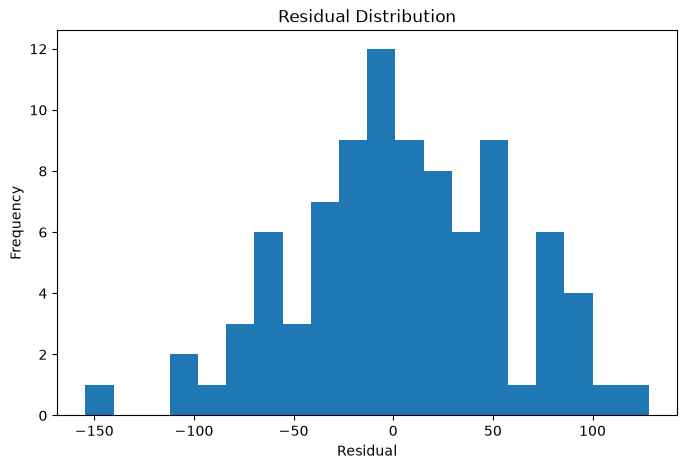

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(test_residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Residual Interpretation

A useful linear model generally has residuals distributed around zero without a strong systematic pattern. Curvature, changing spread, or extreme residuals may suggest nonlinearity, heteroscedasticity, influential observations, or omitted variables.

## 10. Common Mistakes and Best Practices

### Common Mistakes

- Interpreting correlation or fitted coefficients as proof of causation.
- Evaluating a model only on training data.
- Reporting \(R^2\) without considering error magnitude.
- Ignoring residual patterns.
- Applying linear regression to strongly nonlinear relationships without diagnostics.
- Using the deprecated Boston Housing dataset.

### Best Practices

- Separate training and testing data.
- Report several complementary metrics.
- Inspect residual plots.
- document dataset provenance and feature meaning.
- validate assumptions when inference is required.
- use pipelines when preprocessing is needed.
- compare linear regression with appropriate baseline and nonlinear models.

## 11. Exercises

1. Replace the simple dataset with your own ten-point dataset and estimate the line manually.
2. Compare MAE and RMSE. Explain why RMSE is more sensitive to large errors.
3. Change the gradient-descent learning rate and observe convergence.
4. Train the diabetes model using only one feature and compare its test \(R^2\) with the full model.
5. Identify the three largest absolute residuals in the test set.
6. Explain why a high \(R^2\) does not establish causality.
7. Extend the notebook by adding polynomial features and compare the results.

## 12. Key Takeaways

- Linear regression estimates a continuous target using a linear combination of features.
- Ordinary least squares minimizes squared residuals.
- The manual formula, normal equation, gradient descent, and scikit-learn implementation estimate the same underlying model.
- MAE, RMSE, and \(R^2\) describe different aspects of predictive performance.
- Residual analysis is essential for detecting model limitations.
- Multiple regression coefficients must be interpreted conditionally and in context.

## 13. References

- scikit-learn documentation: `LinearRegression`
- scikit-learn documentation: regression metrics
- scikit-learn diabetes dataset documentation
- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning*
- Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*

---

### Next Lesson

Continue with **Polynomial Regression** to model nonlinear relationships using transformed features.

## Lesson Review

### Key Takeaways

- The method should be understood through both its mathematical objective and its implementation.
- Evaluation must use data that were not used to fit the model.
- Preprocessing, model selection, and interpretation are part of the modeling workflow.
- Strong performance metrics do not replace error analysis or domain-aware interpretation.

### Exercises

1. Re-run the main experiment with a different random seed and compare the results.
2. Identify the most important modeling assumption in this lesson.
3. Add at least one additional evaluation metric or diagnostic visualization.
4. Explain one circumstance in which the demonstrated method would be unsuitable.
5. Convert the main workflow into a reusable scikit-learn pipeline where applicable.

### References

- scikit-learn user guide and API documentation
- NumPy and pandas documentation
- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning*
- Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*

---

**Next lesson:** Polynomial Regression